# Kinematic plots for different networks

## Initialisation

In [16]:
import sys
import json
import matplotlib.pyplot as plt
import numpy as np
import argparse
import re

from pathlib import Path
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colorbar import Colorbar
from dataclasses import dataclass


# Get main path of the repository and add it to the path:
try:
    # For scripts
    repo_path = Path(__file__).parent.parent.parent.resolve()
except NameError:
    # For Jupyter notebooks - add the known project root
    repo_path = Path.cwd().parent.parent.resolve()

# Add parent directory to path
sys.path.insert(0, str(repo_path))

# Plot directory:
plot_dir = repo_path / "final_results" / "plots" / "network_comparison"
plot_dir.mkdir(parents=True, exist_ok=True)

from ml_events_utils import stylesheet_default
# from ml_events_utils import color_gio as color_dict
from ml_events_utils import color_deep as color_dict

color_dict = {key: hexwithhash for key, (hex, hexwithhash, floats) in color_dict.items()}

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use(stylesheet_default)

Observables:

- $\sigma_{\mathrm{tot}}$:     (NN/ POWHEG: `totxsec`,    RFR: ``)
- $p_{T, \, e^{+}}$:            (NN/ POWHEG: `ptep`,       RFR: `ptep`)
- $y_{e^{+}}$:                 (NN/ POWHEG: `yep`,        RFR: `yep`)
- $\cos(\theta^{*}_{e^{+}})$:  (NN/ POWHEG: `cthep`,      RFR: `cthep`)
- $m_{Z}$:                     (NN/ POWHEG: `invmass_Z1`, RFR: `mepem`)
- $\Delta \phi_{ee}$:          (NN/ POWHEG: `dphiee`,     RFR: `dphiee`)  # TODO: Adjust LaTex
- $p_{T, \, Z}$:                  (NN/ POWHEG: `ptee`,       RFR: ``)
- $p_{T, \, 4l}$:              (NN/ POWHEG: `pt4l`,       RFR: `pt4l`)
- $r_{\mathrm{LL}}$:           (NN:         `r_LL`,       RFR: `rll`)

In [17]:
observables = {
    "totxsec": {"Autoencoder": "totxsec",    "FFNN": "totxsec",    "PN": "totxsec",    "POWHEG": "totxsec",    "RFR": None},
    "ptep":    {"Autoencoder": "ptep",       "FFNN": "ptep",       "PN": "ptep",       "POWHEG": "ptep",       "RFR": "ptep"},
    "yep":     {"Autoencoder": "yep",        "FFNN": "yep",        "PN": "yep",        "POWHEG": "yep",        "RFR": "yep"},
    "cthep":   {"Autoencoder": "cthep",      "FFNN": "cthep",      "PN": "cthep",      "POWHEG": "cthep",      "RFR": "cthep"},
    "mepem":   {"Autoencoder": "invmass_Z1", "FFNN": "invmass_Z1", "PN": "invmass_Z1", "POWHEG": "invmass_Z1", "RFR": "mepem"},
    "dphiee":  {"Autoencoder": "dphiee",     "FFNN": "dphiee",     "PN": "dphiee",     "POWHEG": "dphiee",     "RFR": "dphiee"},
    "ptee":    {"Autoencoder": "ptee",       "FFNN": "ptee",       "PN": "ptee",       "POWHEG": "ptee",       "RFR": None},
    "pt4l":    {"Autoencoder": "pt4l",       "FFNN": "pt4l",       "PN": "pt4l",       "POWHEG": "pt4l",       "RFR": "pt4l"},
    "rll":     {"Autoencoder": "r_LL",       "FFNN": "r_LL",       "PN": "r_LL",       "POWHEG": None,         "RFR": "rll"},
}

# FIXME: Depending on weather we use the direct POWHEG histograms
#        or the ones generated from the labels r_LL data set
#        we can access "r_LL" for POWHEG or not. Adjust accordingly.

print(f"Get observables like this: {observables['totxsec']['FFNN'] = }.")

observables_latex = {
    "totxsec": r"$\sigma_{\mathrm{tot}}$",
    "ptep":    r"$p_{\mathrm{T}, \, ee}$",
    "yep":     r"$y_{e^{+}}$",
    "cthep":   r"$\cos(\theta^{*}_{e^{+}})$",
    "mepem":   r"$m_{Z}$",
    "dphiee":  r"$\Delta \phi_{ee}$",  # TODO: Adjust LaTex.
    "ptee":    r"$p_{\mathrm{T}, \, Z}$",
    "pt4l":    r"$p_{\mathrm{T}, \, 4l}$",
    "rll":     r"$r_{\mathrm{LL}}$"
}

model_colors = {
    "Autoencoder": color_dict["green"],
    "FFNN":        color_dict["red"],
    "PN":          color_dict["purple"],
    "POWHEG":      color_dict["black"],
    "RFR":         color_dict["blue"],
}

Get observables like this: observables['totxsec']['FFNN'] = 'totxsec'.


## Load the data

1. Put path of the analysis files in dictionary.

In [18]:
autoencoder_path  = repo_path / "final_results" / "autoencoder"
ffnn_path         = repo_path / "final_results" / "ffnn"
pn_path           = repo_path / "final_results" / "pn"
powheg_path       = repo_path / "final_results" / "powheg"
rfr_path          = repo_path / "random_forest_regression"

# Define paths to histogram files and a rescaling factor for each model and order:
# Autoencoder, FFNN, POWHEG are in pb, so we need to rescale it by 1e3 to compare with RFR.
# RFR is in fb.
histogram_paths = {
    "Autoencoder": {
            "LO":    [autoencoder_path / "LO" / "trial_00501" / "LL_pred.top", 1e3],
            "LOwS":  [None, 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [None, 1e3],
           },
    "FFNN": {
            "LO":    [ffnn_path / "LO" / "trial_00128" / "LL_pred.top", 1e3],
            "LOwS":  [None, 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [None, 1e3],
           },
    "PN": {
            "LO":    [pn_path / "LO" / "LL_pred.top", 1e3],
            "LOwS":  [None, 1e3],
            "NLO":   [pn_path / "NLO" / "LL_pred.top", 1e3],
            "NLOPS": [None, 1e3],
           },
    "POWHEG": {
            # "LO":    [powheg_path / "LO" / "LL_true.top", 1e3],
            "LO":    [powheg_path / "LO" / "POWHEG_LL.top", 1e3],
            "LOwS":  [None, 1e3],
            "NLO":   [None, 1e3],
            "NLOPS": [None, 1e3],
           },
    "RFR": {
            "LO":    [rfr_path / "histograms_rfr_ct_lo.top",    1.0],
            "LOwS":  [rfr_path / "histograms_rfr_ct_lows.top",  1.0],
            "NLO":   [rfr_path / "histograms_rfr_ct_nlo.top",   1.0],
            "NLOPS": [rfr_path / "histograms_rfr_ct_nlops.top", 1.0],
           },
}

# Check that files exist:
for model, model_paths in histogram_paths.items():
    for order, (path, _) in model_paths.items():
        if path is not None and not path.exists():
            raise FileNotFoundError(f"File for {model} @ {order} does not exist: {path}")

print(f"Get paths like this: {histogram_paths['RFR']['LO'] = }.")

Get paths like this: histogram_paths['RFR']['LO'] = [PosixPath('/ptmp/mpp/jlinder/ML_Giovanni/polarisation_tagging/random_forest_regression/histograms_rfr_ct_lo.top'), 1.0].


2. Provide a routine which reads in the histograms. Look for lines starting with, for example, `# dphiee` and ignore the possible `index <some number>` which would be there in a proper POWHEG histogram.

In [19]:
from dataclasses import dataclass, field

@dataclass
class HistogramData:
    observable: str
    model: str
    order: str
    left_edges: np.ndarray
    right_edges: np.ndarray
    values: np.ndarray
    errors: np.ndarray
    styles: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self):
        if not self.styles:
            self.styles = {
                "color": model_colors.get(self.model, "black"),
            }

    @property
    def bins(self) -> np.ndarray:
        bins = np.zeros(len(self.left_edges) + 1)
        bins[:-1] = self.left_edges
        bins[-1] = self.right_edges[-1]
        return bins

    def __truediv__(self, other):
        if type(self) is type(other):
            if not np.allclose(self.bins, other.bins):
                raise ValueError("Cannot divide histograms with different bins.")
            new_values = self.values / other.values
            # Propagate errors assuming they are uncorrelated:
            new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
            return HistogramData(
                observable  = self.observable,
                model       = f"{self.model} / {other.model}",
                order       = self.order,
                left_edges  = self.left_edges,
                right_edges = self.right_edges,
                values      = new_values,
                errors      = new_errors,
                styles      = self.styles
            )


def read_histogram(path: Path,
                   rescaling_factor: float,
                   observable_map: Dict[str, str],
                   model: str,
                   order:str) -> Dict[str, Any]:
    """Read a histogram file and return a dictionary of histograms."""

    histograms = {}
    aligned_observable_name = None
    with open(path, "r") as f:
        in_histogram = False
        for line in f:
            line = line.strip()
            if not line and not in_histogram:
                continue

            if line.startswith("#") and not in_histogram:
                match = re.match(r"#\s*([a-zA-Z0-9_-]+)\s*", line)
                if not match:
                    continue
                observable = match.group(1)
                aligned_observable_name = observable_map.get(observable, observable)
                histograms[aligned_observable_name] = []
                in_histogram = True
                continue

            if in_histogram:
                for char in ["d", "D", "E"]:
                    line = re.sub(rf"{char}", "e", line)

                parts = line.split()
                if len(parts) != 4:
                    in_histogram = False
                    histograms[aligned_observable_name] = HistogramData(
                        observable = aligned_observable_name,
                        model      = model,
                        order      = order,
                        left_edges =  np.array(histograms[aligned_observable_name])[:, 0],
                        right_edges = np.array(histograms[aligned_observable_name])[:, 1],
                        values     =  np.array(histograms[aligned_observable_name])[:, 2],
                        errors     =  np.array(histograms[aligned_observable_name])[:, 3]
                    )
                    continue

                values = np.array(list(map(float, parts[:])))
                values[2:4] *= rescaling_factor
                histograms[aligned_observable_name].append(values)

        # Handle the last histogram if the file ends while reading histogram data
        if in_histogram and aligned_observable_name is not None and isinstance(histograms[aligned_observable_name], list):
            histograms[aligned_observable_name] = HistogramData(
                observable = aligned_observable_name,
                model      = model,
                order      = order,
                left_edges =  np.array(histograms[aligned_observable_name])[:, 0],
                right_edges = np.array(histograms[aligned_observable_name])[:, 1],
                values     =  np.array(histograms[aligned_observable_name])[:, 2],
                errors     =  np.array(histograms[aligned_observable_name])[:, 3]
            )

    return histograms


3. Read in the histograms and align observable names.

In [20]:
model_histograms = {}
for model, model_paths in histogram_paths.items():
    model_histograms[model] = {}
    observable_map_model = {obs_info[model]: obs for obs, obs_info in observables.items()}
    for order, (path, rescaling_factor) in model_paths.items():
        if path is not None:
            print(f"Reading histogram for {model} @ {order} from {path}.")
            model_histograms[model][order] = read_histogram(path, rescaling_factor, observable_map=observable_map_model, model=model, order=order)
            print(f"Available observables for {model} @ {order}: {list(model_histograms[model][order].keys())}")

# test_histogram = read_histogram(histogram_paths["RFR"]["LO"][0], histogram_paths["RFR"]["LO"][1], observable_map=observables, model="RFR")

print(f"Get histograms like this: {model_histograms['RFR']['LO']['ptep'] = }.")
print(f"Access bins like this: {model_histograms['RFR']['LO']['ptep'].bins = }.")
print("Have fun plotting! :)")

Reading histogram for Autoencoder @ LO from /ptmp/mpp/jlinder/ML_Giovanni/polarisation_tagging/final_results/autoencoder/LO/trial_00501/LL_pred.top.
Available observables for Autoencoder @ LO: ['totxsec', 'mepem', 'ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for FFNN @ LO from /ptmp/mpp/jlinder/ML_Giovanni/polarisation_tagging/final_results/ffnn/LO/trial_00128/LL_pred.top.
Available observables for FFNN @ LO: ['totxsec', 'mepem', 'ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for PN @ LO from /ptmp/mpp/jlinder/ML_Giovanni/polarisation_tagging/final_results/pn/LO/LL_pred.top.
Available observables for PN @ LO: ['totxsec', 'mepem', 'ptee', 'cthep', 'ptep', 'yep', 'pt4l', 'dphiee', 'rll', 'r_LL_count']
Reading histogram for PN @ NLO from /ptmp/mpp/jlinder/ML_Giovanni/polarisation_tagging/final_results/pn/NLO/LL_pred.top.
Available observables for PN @ NLO: ['totxsec', 'mepem', 'ptee', 'cthep', 'ptep', 'y

## Plotting routine for ordinary kinematic data

In [28]:
def get_histograms_for_observable(histograms, observable, order):
    histograms_for_observable = {}
    for model, model_histograms in histograms.items():
        if order in model_histograms and observable in model_histograms[order]:
            histograms_for_observable[model] = model_histograms[order][observable]
    return histograms_for_observable

def add_legend(ax, legloc:str="", **kwargs):
    """Set legend of a plot.

    Args:
        ax (_type_): Ax object of the plot for which the legend should be set.
        legloc (str, optional): Specify manually the location of the legend. Defaults to "best".
        Select from ['left', 'center', 'right'] and combine with ['upper', 'center', 'lower'], like
            'upper right'
        leg_edge (bool, optional): Specifiy wether edge of legend should be shown. Defaults to False.
        leg_bg_alpha (float, optional): Specify transparency of background. Defaults to transparent, i.e. 0.0.
        ncol (int, optional): Number of columns for the legend. Defaults to 1 (labels stacked vertically).
            Set to a higher value to arrange labels horizontally next to each other.
    """
    handles, labels = ax.get_legend_handles_labels()
    try:
        new_handles = [plt.Line2D([], [], ls=h.get_linestyle(), c=h.get_edgecolor(), linewidth=h.get_linewidth()) for h in handles]
    except AttributeError:
        new_handles = [plt.Line2D([], [], marker=h.get_marker(), ls=h.get_linestyle(), c=h.get_color(), linewidth=h.get_linewidth()) for h in handles]

    ncol = kwargs.get("ncol", 1)

    if legloc:
        ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)
    else:
        ax.legend(handles = new_handles, labels=labels, ncol=ncol)

    leg = ax.get_legend()
    if kwargs.get("leg_edge", False):
        leg.get_frame().set_linewidth(1.0)
    else:
        leg.get_frame().set_linewidth(0.0)

    gray = [0.655, 0.655, 0.659]
    leg.get_frame().set_edgecolor(gray)

    # Change alpha of background without changing the transparency of the frame edge.
    if bg := kwargs.get("leg_bg_alpha", False):
        facealpha = bg
    else:
        facealpha = 0.0
    leg.get_frame().set_alpha(None)
    leg.get_frame().set_facecolor(([1,1,1], facealpha))


def add_uncertainty_bands(ax, bs, ws, sigs_stat, sigs_syst=[], clr: str = 'black', ls: str = '-', bands: bool = True):
    """Plots uncertainty bands or error bars on a given axis.

        ax (matplotlib.axes.Axes): The matplotlib axis on which to plot the uncertainty bands or error bars.
        bs (array-like): Bin edges for the data.
        ws (array-like): Bin values or weights corresponding to the bins.
        sigs_stat (array-like): Statistical uncertainties for each bin.
        sigs_syst (array-like, optional): Systematic uncertainties for each bin. Defaults to an empty list.
        clr (str, optional): Color of the uncertainty bands or error bars. Defaults to 'black'.
        ls (str, optional): Line style for the uncertainty boundaries. Defaults to '-'.
        bands (bool, optional): If True, plots uncertainty bands; otherwise, plots error bars. Defaults to True.

    Returns:
        None
    """
    if bands:
        # axs[0].bar(x=bs[:-1], height=2*sigs_stat, bottom=ws-sigs_stat, width=np.diff(bs), align='edge', linewidth=0, alpha=0.25, zorder=-1, color=color_hist0)
        up   = ws + sigs_stat
        # up   = np.append(up,   up[-1])
        down = ws - sigs_stat
        # down = np.append(down, down[-1])

        bins = bs[:-1] + np.diff(bs)/2
        ax.fill_between(bins, down, up, step='post', color=clr, alpha=0.25, zorder=-1)
        ax.step(bins, up,   where='post', color=clr, linestyle=ls, alpha=0.5, marker='')
        ax.step(bins, down, where='post', color=clr, linestyle=ls, alpha=0.5, marker='')
    else:
        ax.errorbar(bs[1:], ws, yerr=sigs_stat, marker="", linestyle="", color=clr)


def plot_histograms(ax, weights_sig, labels, styles:list=[], uncertainties=False):
    """
    Plot histograms on the given axis.

    Parameters:
        ax: The axis to plot on.
        weights_sig: A list of tuples (bin_edges[0:n+1], weights[0:n], sigs_stat[0:n]) for each histogram to plot.
        labels: A list of labels for the histograms.
        styles: A list of style dictionaries for each histogram (e.g. color, linestyle).
                To change, for example, only the color of the second histogram, you can provide styles=[{}, {"color": "red"}, {}, ...].
        uncertainties: Whether to plot uncertainty bands.
    """
    if labels is None:
        labels = [None,] * len(weights_sig)
    if not styles:
        styles = [{},] * len(weights_sig)

    default_style = {"alpha": 1.0, "marker": "", "linestyle": "-"}  # Color is set by the color cycle or by the user-provided styles.
    for i, (bs, ws, sigs_stat) in enumerate(weights_sig):
        # Use step instead of hist to avoid edge lines at the sides
        style_settings = default_style.copy()
        style_settings.update(styles[i])
        line = ax.step(bs[:-1] + np.diff(bs)/2, ws, where='post', label=labels[i], **style_settings)

        if uncertainties:
            hist_colour    = line[0].get_color()
            hist_linestyle = line[0].get_linestyle()
            add_uncertainty_bands(ax, bs, ws, sigs_stat, clr=hist_colour, ls=hist_linestyle, bands=True)



In [29]:
def plot_mem_observable(histograms: dict,
                        xrange: list,
                        title:str,
                        xlabel:str,
                        unit:str,
                        ylabel1:str,
                        yranges:list=[],
                        logs:list = [False, False],
                        legends:list=[{}, {}],
                        rcParams:dict={},):

    """
    histogram: dict = {
                       "model1": histogram,
                       "model2": histogram,
                      }
    Plots:
        Oben:
        Ratio1:
        Ratio2:
    """

    with plt.style.context(stylesheet_default):
        mpl.rcParams.update(rcParams)
        size = mpl.rcParams['figure.figsize']
        n_plots = 2
        scale_factor = 1.0 + 0.5*(n_plots-1)
        height_ratios = [3,] + [1,]*(n_plots-1)
        fig, axs = plt.subplots(n_plots, 1, sharex=True, figsize=(size[0], scale_factor*size[1]), height_ratios=height_ratios)
        ylabels = ["",] * n_plots

        weights_sig = []
        styles = []
        labels = list(histograms.keys())
        for histogram in histograms.values():
            weights_sig.append((histogram.bins, histogram.values, histogram.errors))
            styles.append(histogram.styles)

        plot_histograms(axs[0], weights_sig, labels=labels, styles=styles, uncertainties=True)
        ylabels[0] = ylabel1

        # ratios w.r.t powheg:
        if histograms.get("POWHEG", None):
            ref_histogram = histograms["POWHEG"]
            ref_name = "POWHEG"
        # elif histograms.get("FFNN", None):
        #     ref_histogram = histograms["FFNN"]
        #     ref_name = "FFNN"
        elif histograms.get("RFR", None):
            ref_histogram = histograms["RFR"]
            ref_name = "RFR"
        # elif histograms.get("Autoencoder", None):
        #     ref_histogram = histograms["Autoencoder"]
        #     ref_name = "Autoencoder"
        # elif histograms.get("PN", None):
        #     ref_histogram = histograms["PN"]
        #     ref_name = "PN"
        else:
            ref_histogram = list(histograms.values())[0]
            ref_name = ref_histogram.model

        weights_sig = []
        styles = []
        for i, (model, histogram) in enumerate(histograms.items()):
            if model == "POWHEG":
                continue
            ratio_histogram = histogram / ref_histogram
            weights_sig.append((ratio_histogram.bins, ratio_histogram.values, ratio_histogram.errors))
            styles.append(histogram.styles)

        plot_histograms(axs[1], weights_sig, labels=None, styles=styles, uncertainties=True)
        axs[1].axhline(1.0, color=color_dict['black'], linestyle='--', linewidth=1)

        ylabels[1] = f"X / {ref_name}"

        # axs[0].text(
        #     0.02,
        #     0.98,
        #     "Dashed: LO\nSolid: NLO",
        #     transform=axs[0].transAxes,
        #     va='top',
        #     ha='left',
        #     # bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "gray"},
        # )

        axs[0].set_title(title)
        if unit:
            xlabel  += f" [{unit}]"

        axs[n_plots-1].set_xlabel(xlabel)

        for i, log, yrange, legend in zip(list(range(n_plots)), logs, yranges, legends):
            axs[i].set_ylabel(ylabels[i])
            if log:
                axs[i].set_yscale('log')
            if yrange:
                axs[i].set_ylim(yrange)

            if legend:
                add_legend(axs[i], **legend)
            else:
                add_legend(axs[i], legloc="lower left")

        return fig, axs

## Plot

Plotting observable ptep @ LO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


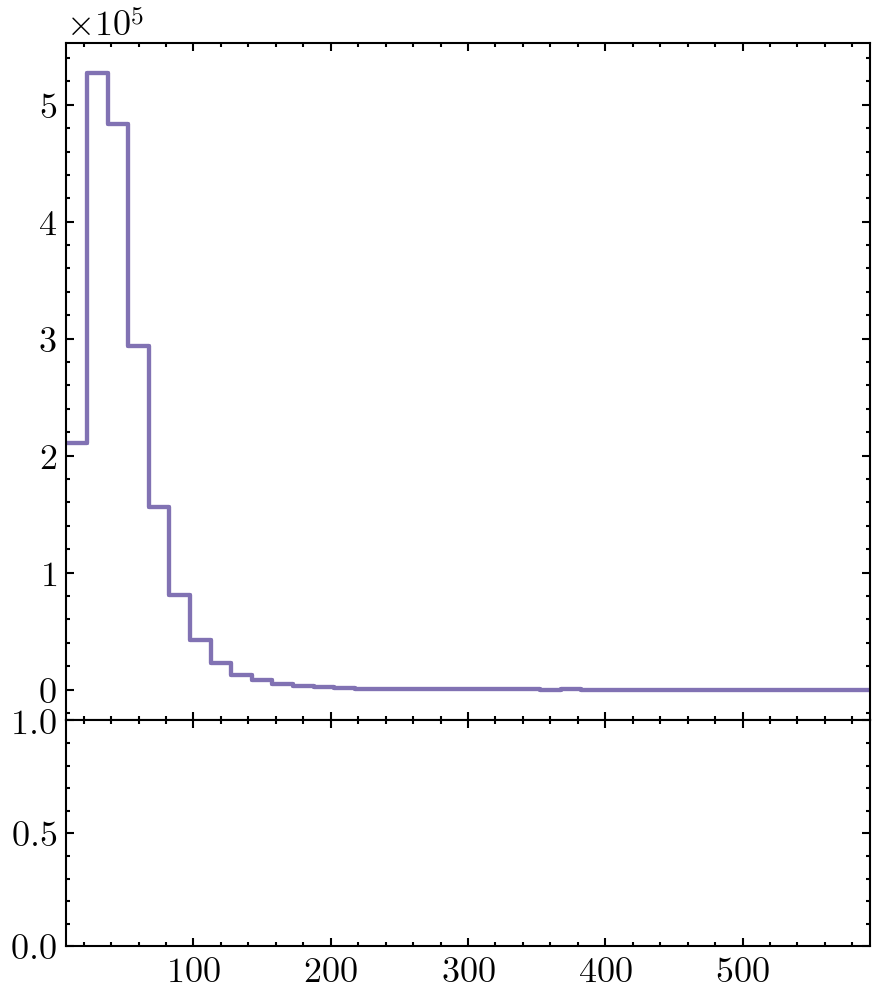

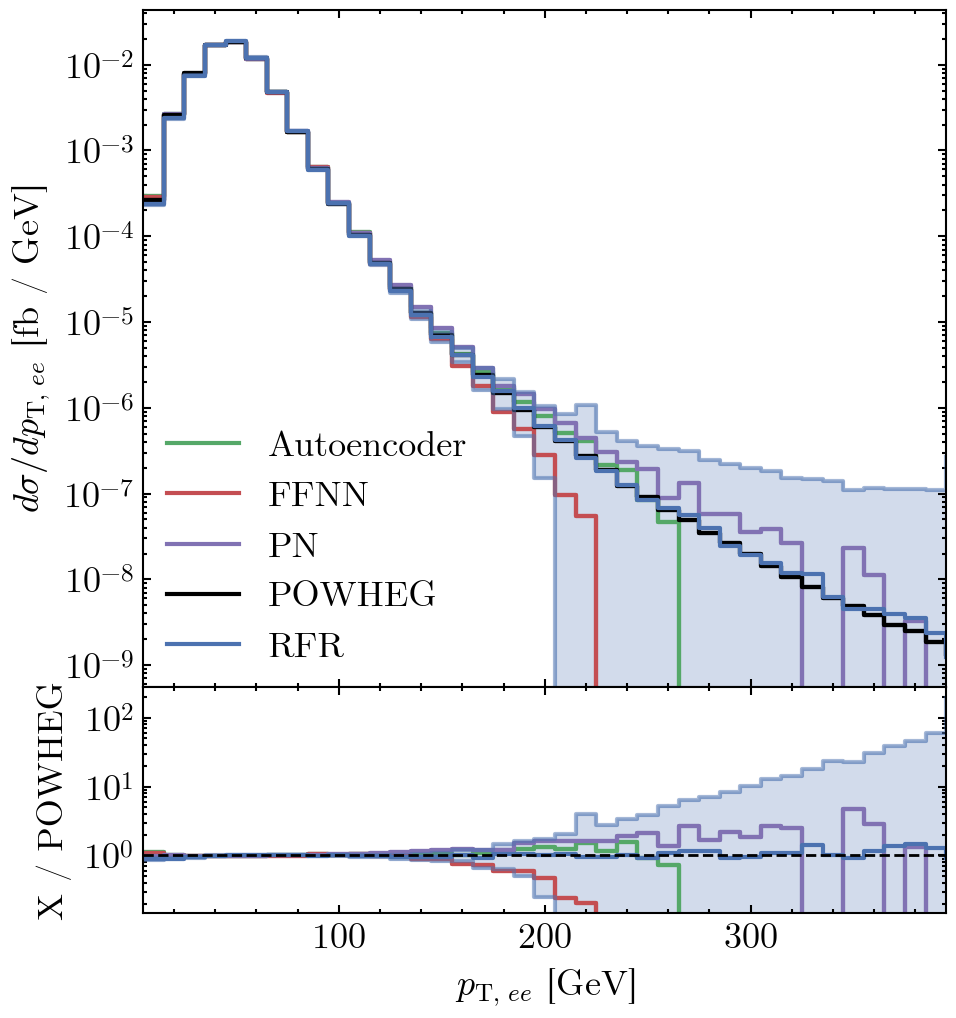

Plotting observable yep @ LO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


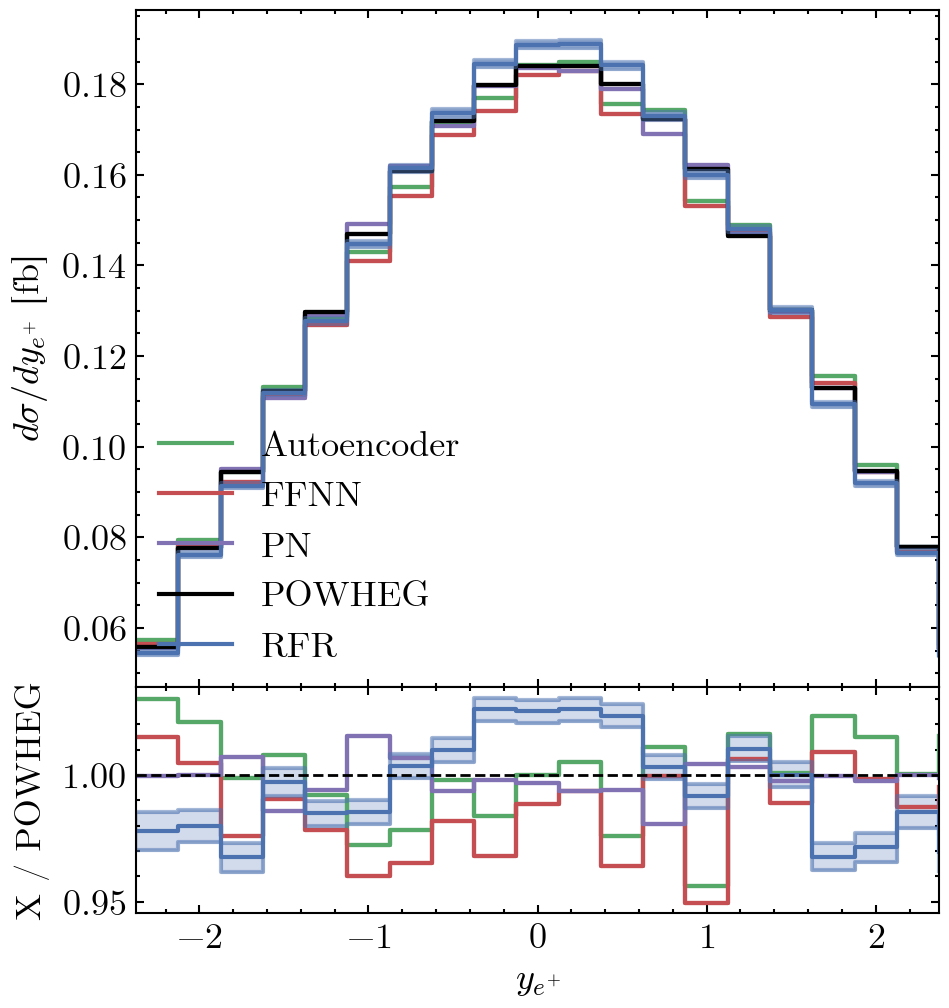

Plotting observable cthep @ LO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


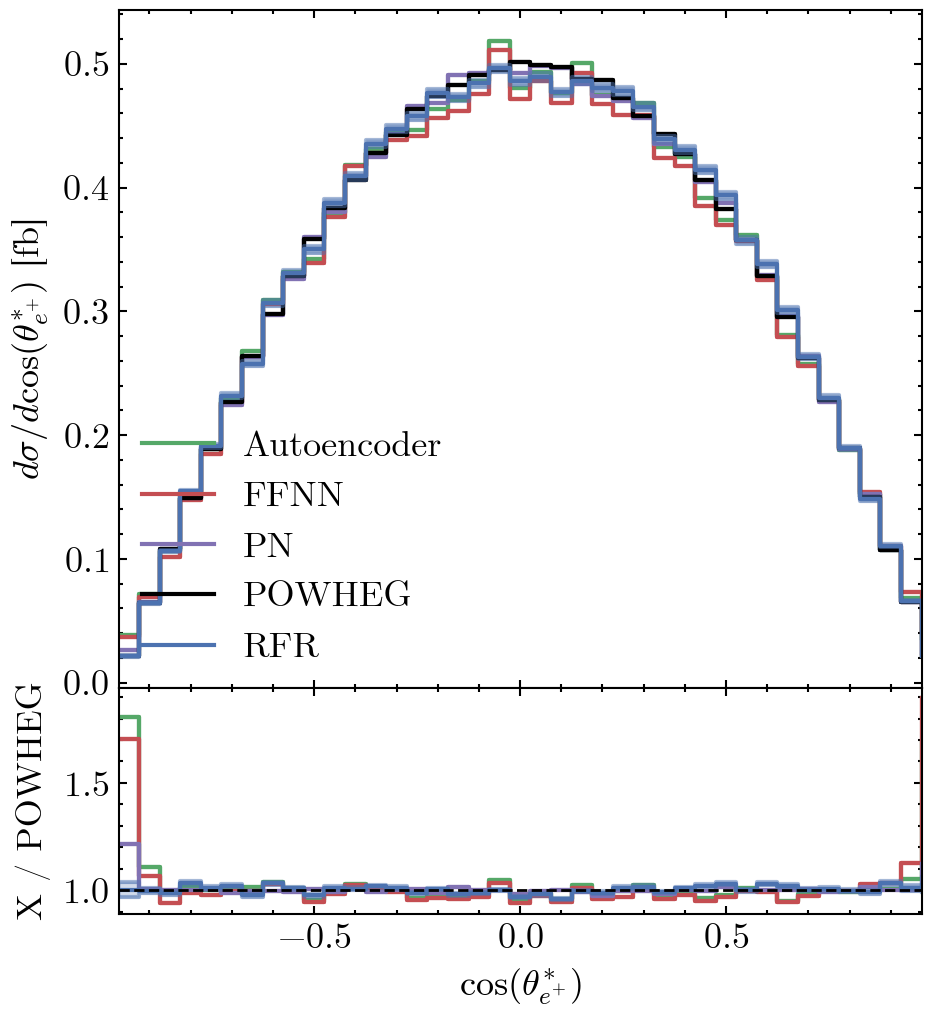

Plotting observable mepem @ LO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


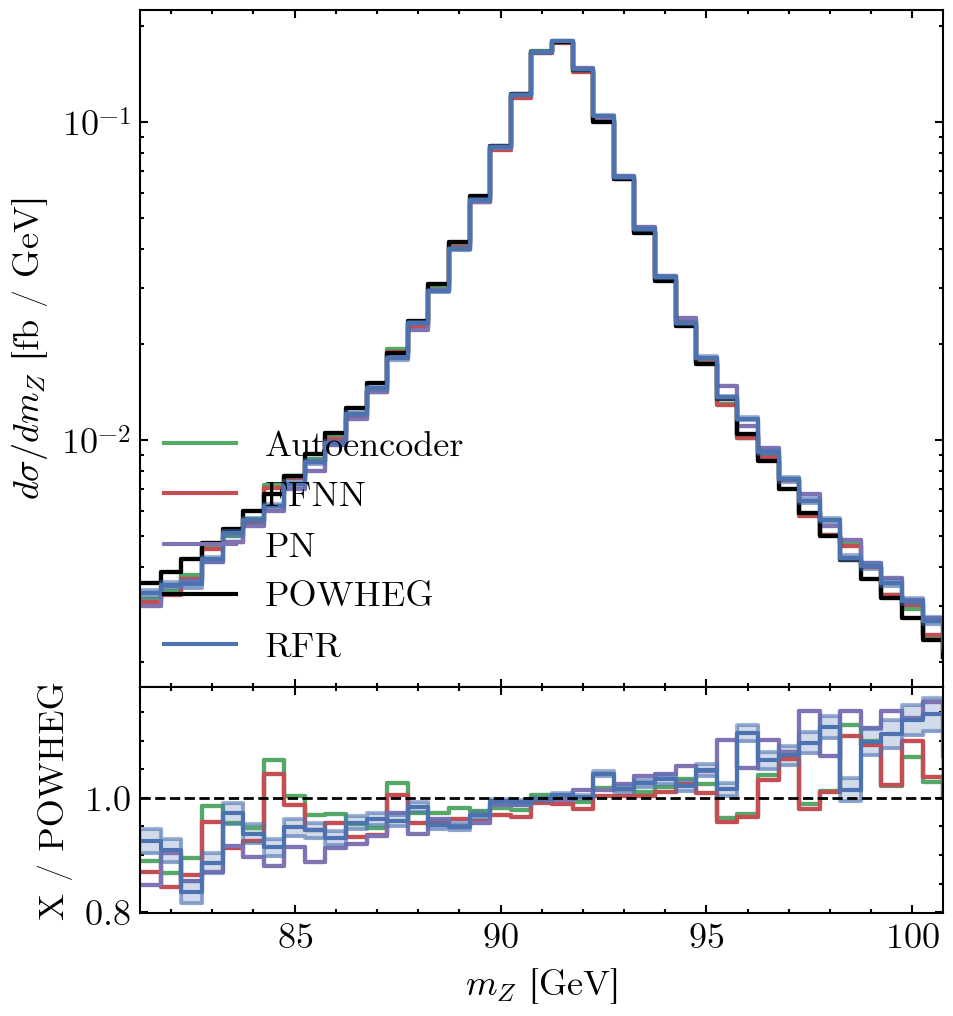

Plotting observable dphiee @ LO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


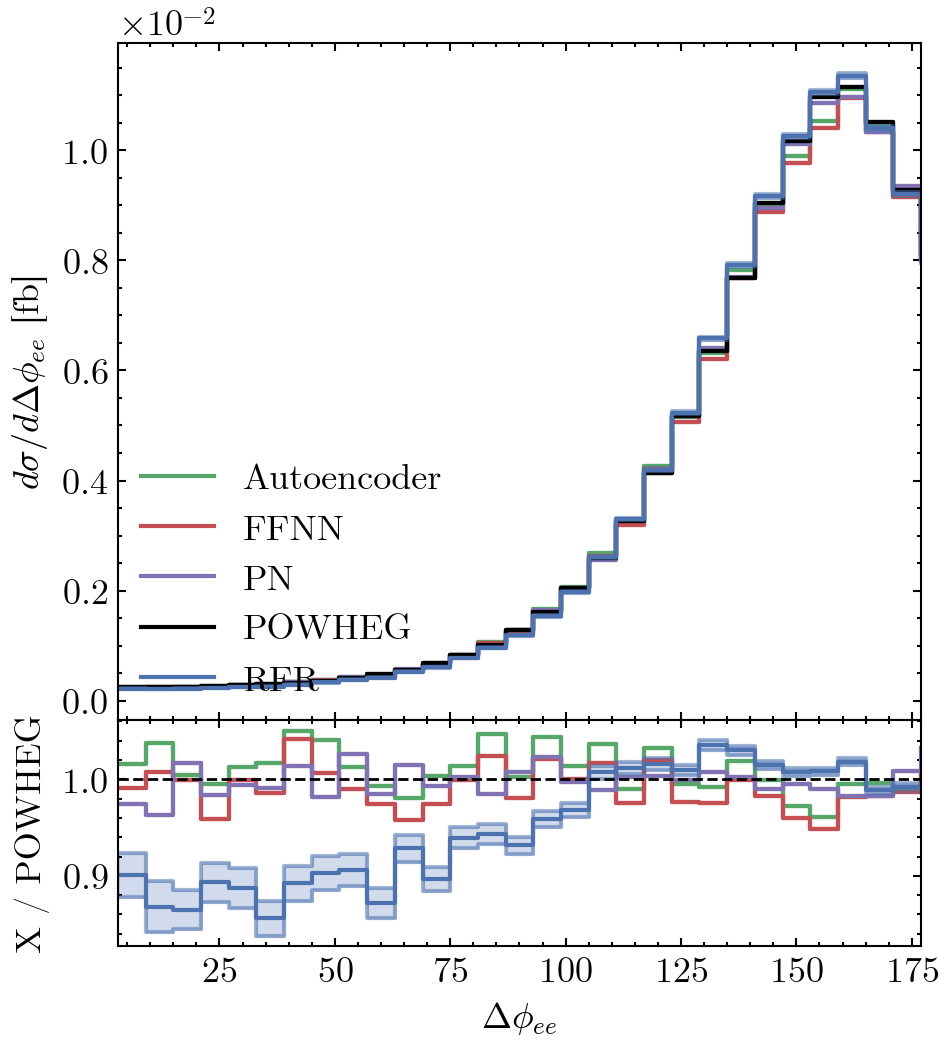

Plotting observable ptee @ LO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


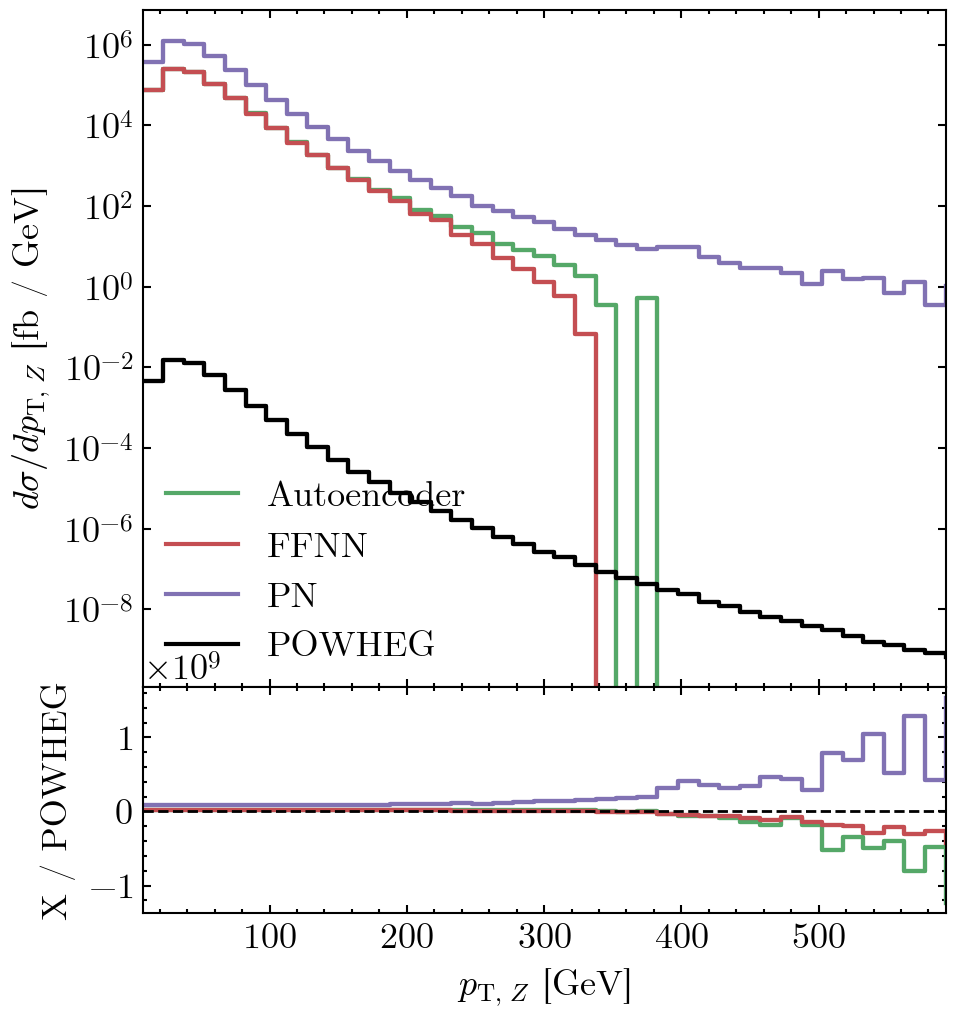

Plotting observable pt4l @ LO.


/tmp/ipykernel_762682/980896594.py:31: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/tmp/ipykernel_762682/980896594.py:33: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


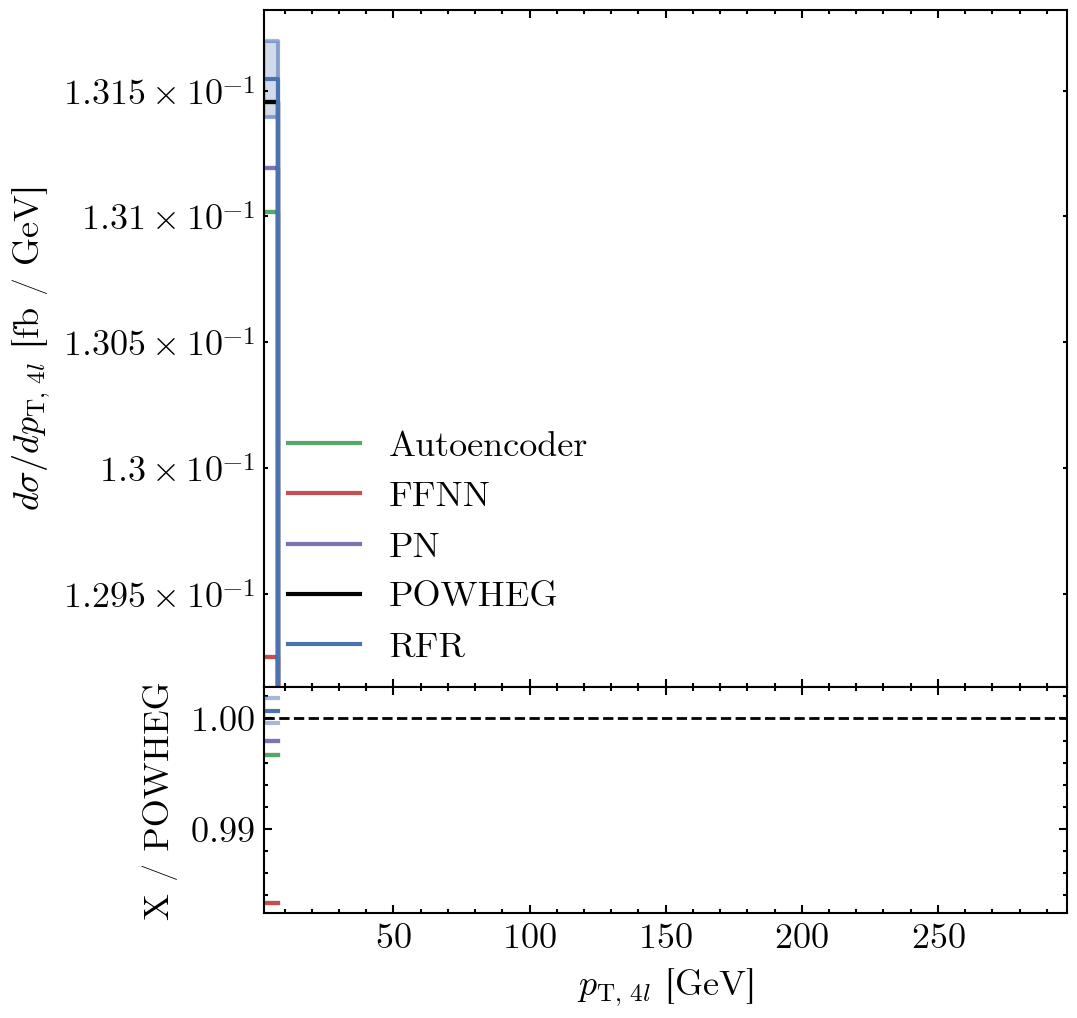

Plotting observable rll @ LO.


/tmp/ipykernel_762682/980896594.py:31: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/tmp/ipykernel_762682/980896594.py:31: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/tmp/ipykernel_762682/980896594.py:33: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


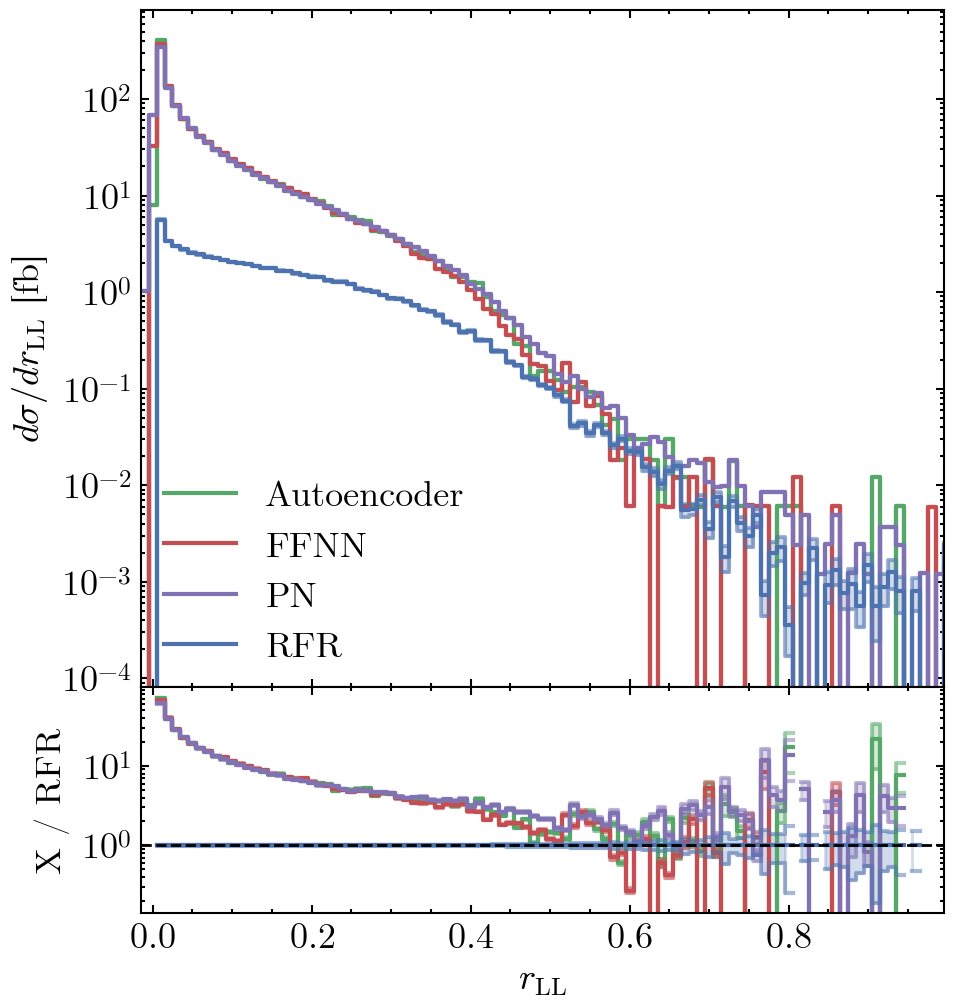

Plotting observable ptep @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


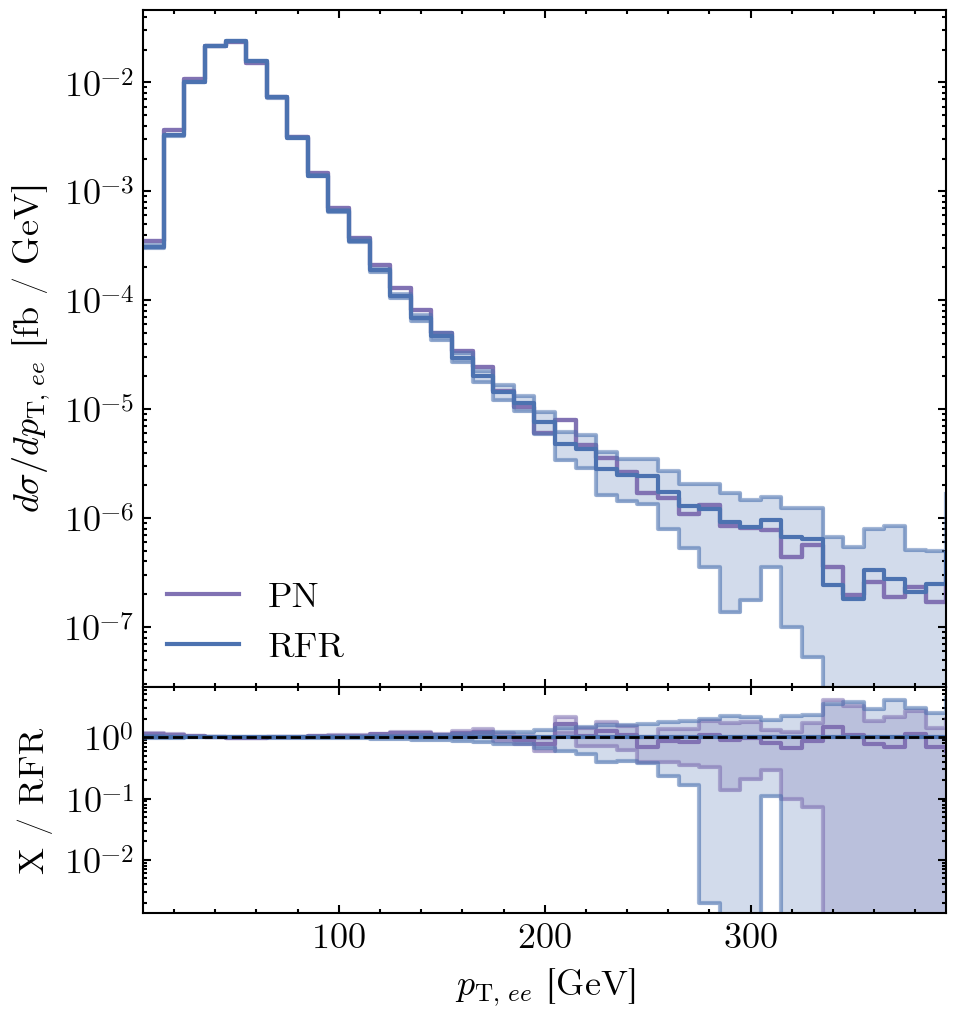

Plotting observable yep @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


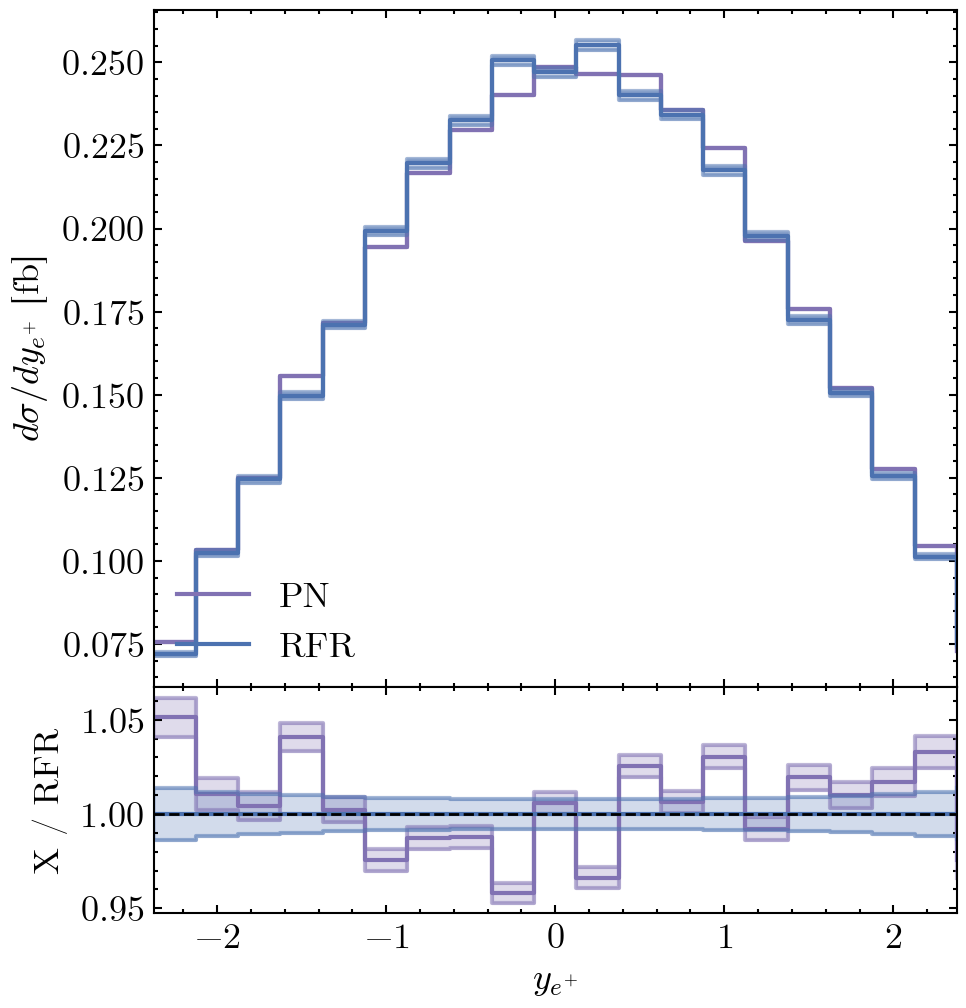

Plotting observable cthep @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


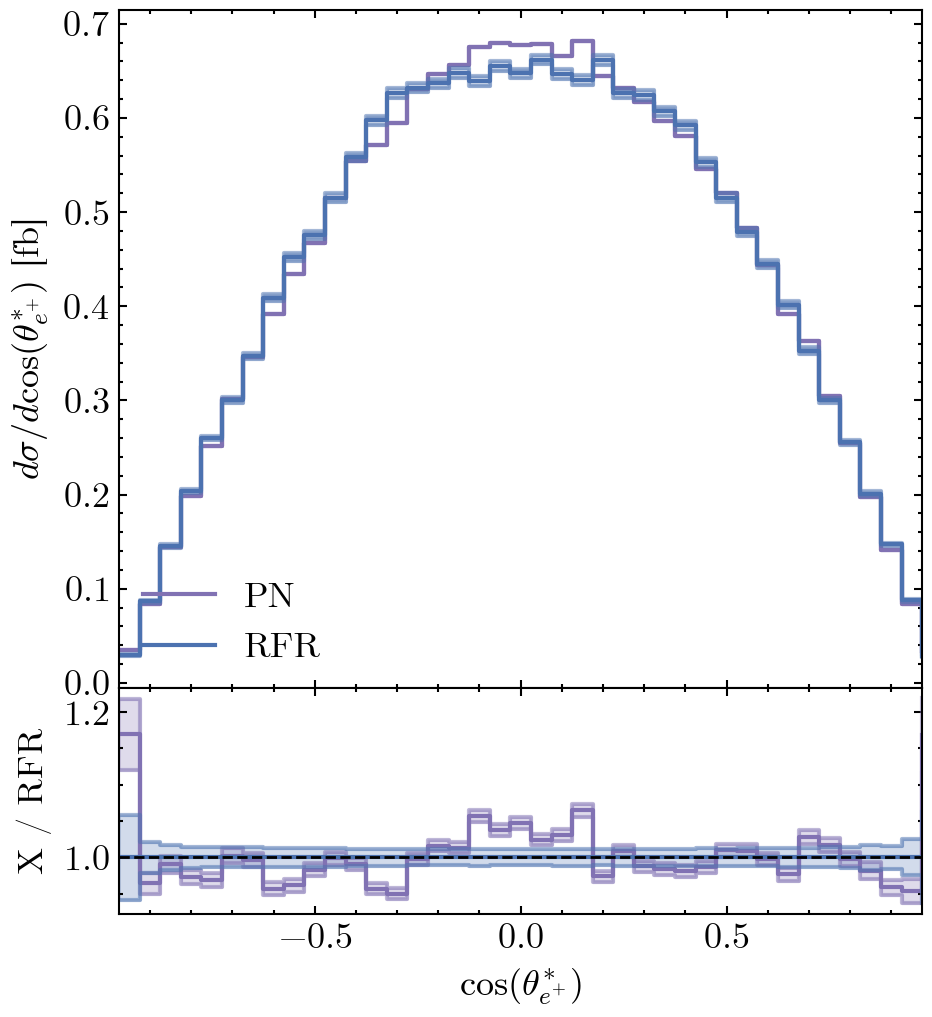

Plotting observable mepem @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


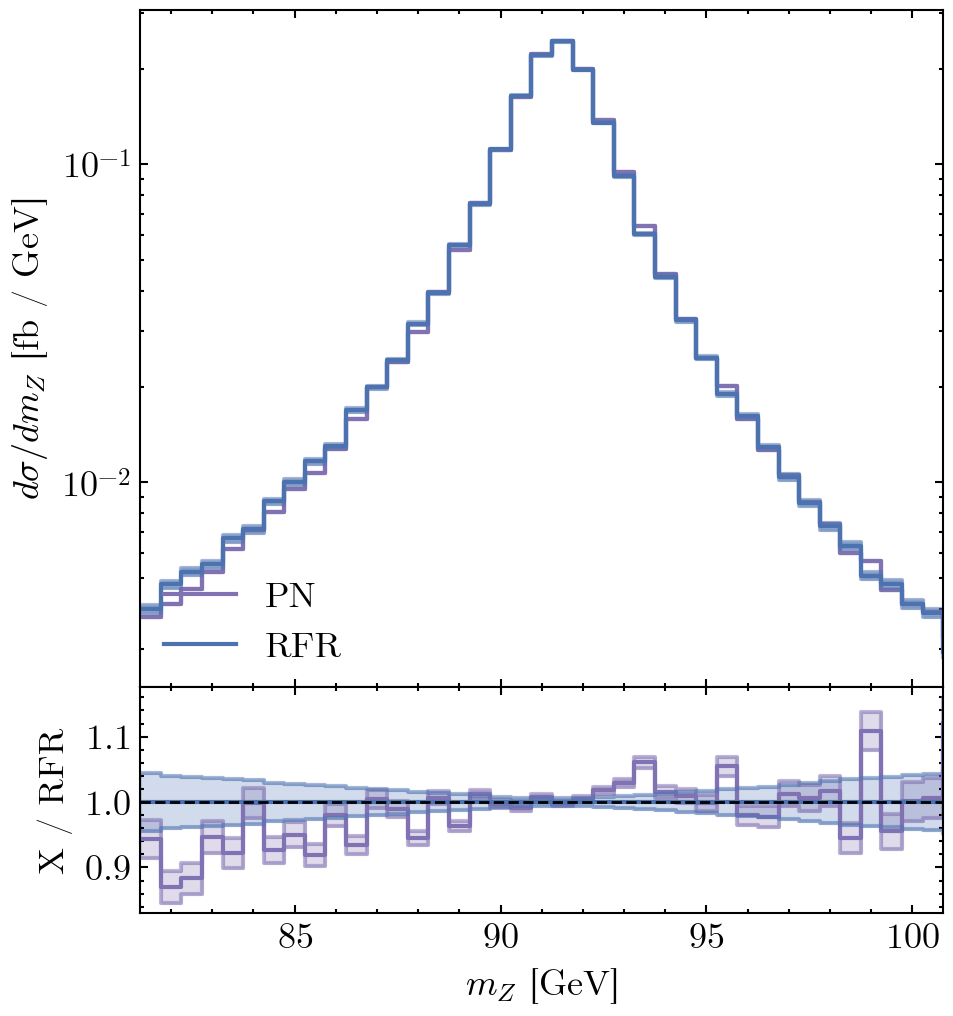

Plotting observable dphiee @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


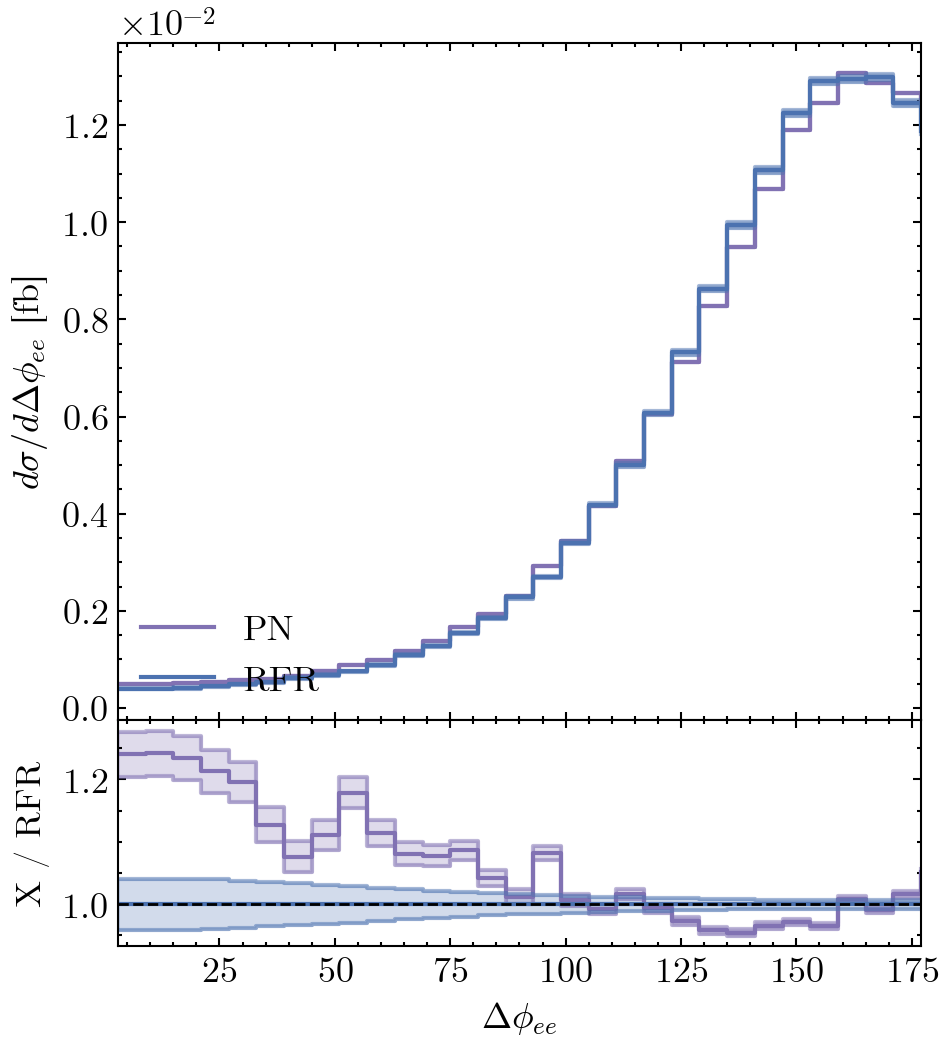

Plotting observable ptee @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


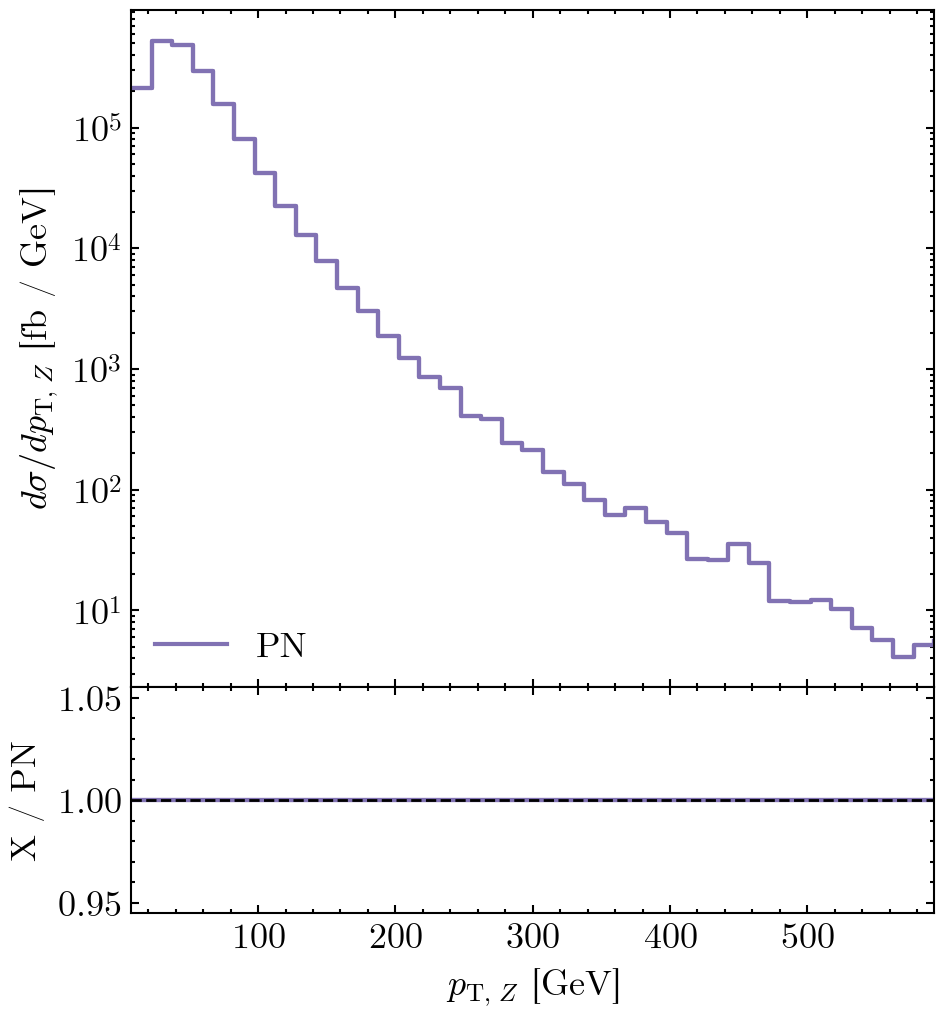

Plotting observable pt4l @ NLO.


/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


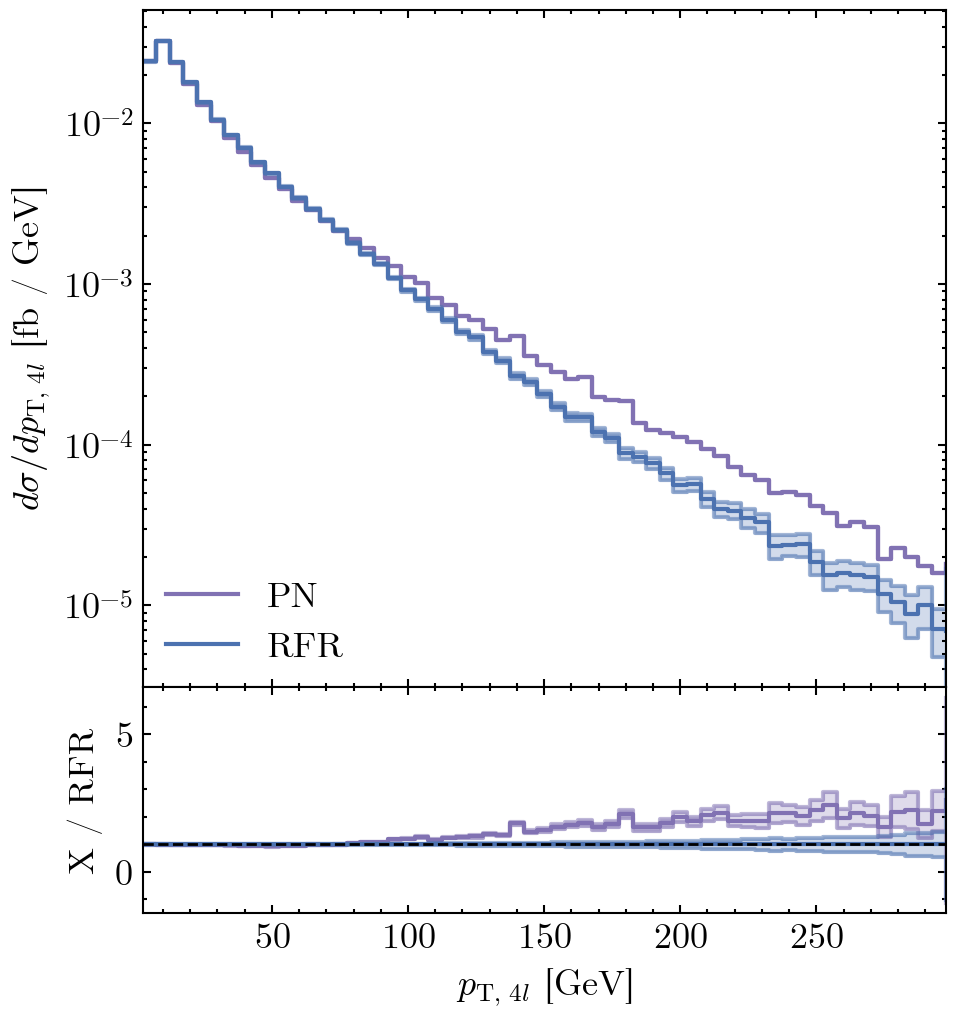

Plotting observable rll @ NLO.


/tmp/ipykernel_762682/980896594.py:31: RuntimeWarning: divide by zero encountered in divide
  new_values = self.values / other.values
/tmp/ipykernel_762682/980896594.py:31: RuntimeWarning: invalid value encountered in divide
  new_values = self.values / other.values
/tmp/ipykernel_762682/980896594.py:33: RuntimeWarning: invalid value encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/tmp/ipykernel_762682/980896594.py:33: RuntimeWarning: divide by zero encountered in divide
  new_errors = np.sqrt((self.errors / other.values) ** 2 + (self.values * other.errors / other.values ** 2) ** 2)
/tmp/ipykernel_762682/3365473037.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles = new_handles, labels=labels, loc=legloc, ncol=ncol)


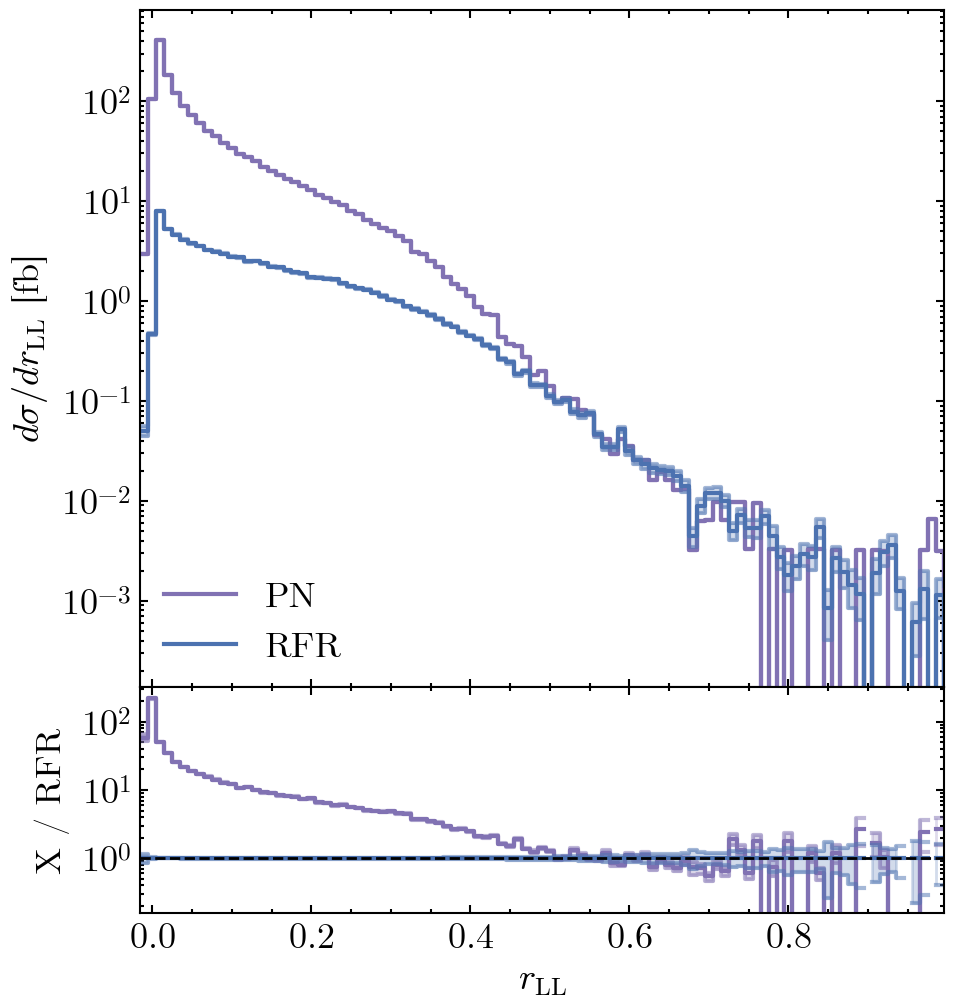

In [30]:
plot_observables = {
    # observables_key: [tex_xlabel, unit, xrange and bin width, [yrange1, yrange2], [log1, log2], [legend1, legend2]]
    "ptep"    : [observables_latex["ptep"],    r"GeV", [], [[], []], [True,  True],  [{}, {}], ],
    "yep"     : [observables_latex["yep"],     r"",    [], [[], []], [False, False], [{}, {}], ],
    "cthep"   : [observables_latex["cthep"],   r"",    [], [[], []], [False, False], [{}, {}], ],
    "mepem"   : [observables_latex["mepem"],   r"GeV", [], [[], []], [True,  False], [{}, {}], ],
    "dphiee"  : [observables_latex["dphiee"],  r"",    [], [[], []], [False, False], [{}, {}], ],
    "ptee"    : [observables_latex["ptee"],    r"GeV", [], [[], []], [True,  False], [{}, {}], ],
    "pt4l"    : [observables_latex["pt4l"],    r"GeV", [], [[], []], [True,  False], [{}, {}], ],
    "rll"     : [observables_latex["rll"],     r"",    [], [[], []], [True,  True],  [{}, {}], ],
}


metadata = {'Title': "Kinematic distributions for different models",
            'Author': 'Jakob Linder',
            'CreationDate': datetime.today(),
            'ModDate': datetime.today(),
            'Creator': 'Python'}

fp_rcParams = {}

# for order in ["LO", "LOwS", "NLO", "NLOPS"]:
for order in ["LO", "NLO"]:
    file = plot_dir / Path(f"network_comparison_{order.lower()}.pdf")
    metadata['Title'] = f"Kinematic distributions for different models @ {order}"
    with PdfPages(filename=file, metadata=metadata) as pdf:
        for fp_observable, (fp_xlabel, fp_unit, fp_xrange, fp_yranges, fp_logs, fp_legends) in plot_observables.items():
            print(f"Plotting observable {fp_observable} @ {order}.")

            histograms = get_histograms_for_observable(model_histograms, fp_observable, order)

            fp_title  = f""
            fp_ylabel1 = r"$d \sigma / d " + fp_xlabel[1:-1] + r"$ [fb]"
            if fp_unit:
                fp_ylabel1 = fp_ylabel1[:-1] + f" / {fp_unit}]"


            fig, axs = plot_mem_observable(histograms, xrange=fp_xrange, title=fp_title, xlabel=fp_xlabel, unit=fp_unit, ylabel1=fp_ylabel1, yranges=fp_yranges, logs=fp_logs, legends=fp_legends, rcParams=fp_rcParams)

            pdf.savefig(fig)
            plt.show()

